# Project Name - Aerial Object Classification & Detection

### Project Type - Unsupervised

## Project Summary - 

The goal of this project is to build an image classification system capable of distinguishing between different classes (e.g., bird vs drone) using deep learning techniques. The project leverages transfer learning to improve performance and reduce training time.

## Github link:

https://github.com/arup81/Aerial-Object-Classification-Detection.git

In [1]:
# ANN model building

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 224, 224, 3)  0           ['input_1[0][0]']                
                                                                                                  
 normalization (Normalization)  (None, 224, 224, 3)  7           ['rescaling[0][0]']              
                                                                     

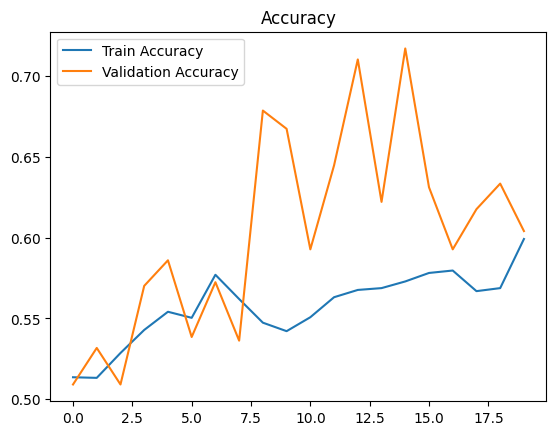

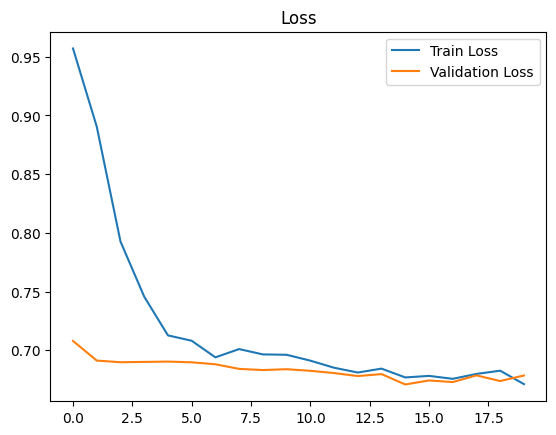

7/7 [==============================] - 2s 201ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.88      0.80       121
           1       0.79      0.57      0.67        94

    accuracy                           0.75       215
   macro avg       0.76      0.73      0.73       215
weighted avg       0.76      0.75      0.74       215


Confusion Matrix:
[[107  14]
 [ 40  54]]
✅ Weights saved successfully!


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# =========================
# 1. Paths
# =========================

train_dir = r"D:\Arup\AI_ML\LABMENTIX\Project Work\05_260402\Submission_260402\classification_dataset\train"
val_dir = r"D:\Arup\AI_ML\LABMENTIX\Project Work\05_260402\Submission_260402\classification_dataset\valid"
test_dir = r"D:\Arup\AI_ML\LABMENTIX\Project Work\05_260402\Submission_260402\classification_dataset\test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# =========================
# 2. Data Generators
# =========================

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# =========================
# 3. Load Pretrained Model
# =========================

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# =========================
# 4. Build Custom Classifier
# =========================

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

# =========================
# 5. Compile Model
# =========================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================
# 6. Callbacks
# =========================

callbacks = [
    EarlyStopping(
        patience=5,
        restore_best_weights=True
    )
]

# =========================
# 7. Train Model
# =========================

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks
)

# =========================
# 8. Plot Training Results
# =========================

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.legend()
plt.show()

# =========================
# 9. Model Evaluation
# =========================

predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

print("\nClassification Report:")
print(classification_report(test_data.classes, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(test_data.classes, y_pred))

# =========================
# 10. Save Model
# =========================

os.makedirs("models", exist_ok=True)

model.save_weights("models/model_weights.h5")

print("✅ Weights saved successfully!")

In [3]:
# Transfer Learning: Using EfficientNetB0 and fine-tune

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
Class Mapping: {'bird': 0, 'drone': 1}
Class Weights: {0: 0.9413012729844413, 1: 1.0665064102564104}
Epoch 1/20
84/84 [==============================] - 29s 276ms/step - loss: 1.0401 - accuracy: 0.5049 - val_loss: 0.6917 - val_accuracy: 0.4977
Epoch 2/20
84/84 [==============================] - 23s 276ms/step - loss: 0.8561 - accuracy: 0.5316 - val_loss: 0.6903 - val_accuracy: 0.5113
Epoch 3/20
84/84 [==============================] - 23s 273ms/step - loss: 0.8378 - accuracy: 0.5222 - val_loss: 0.6903 - val_accuracy: 0.5090
Epoch 4/20
84/84 [==============================] - 24s 289ms/step - loss: 0.7755 - accuracy: 0.5349 - val_loss: 0.6913 - val_accuracy: 0.5090
Epoch 5/20
84/84 [==============================] - 23s 278ms/step - loss: 0.7385 - accuracy: 0.5244 - val_loss: 0.6920 - val_accuracy: 0.5792
Epoch 6/20
84/84 [==============================] - 23s 276m

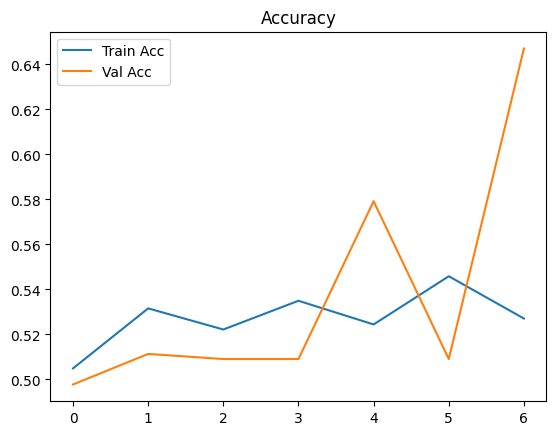

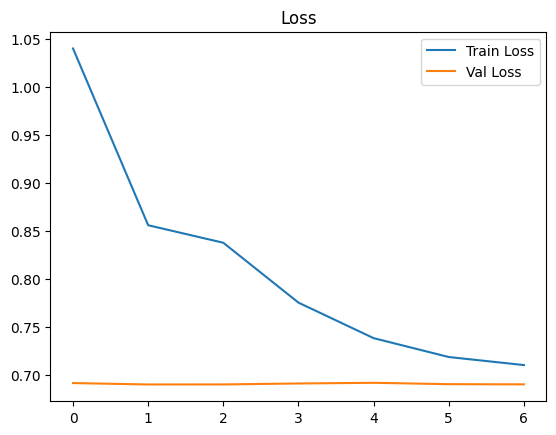

7/7 [==============================] - 2s 208ms/step

Classification Report:
              precision    recall  f1-score   support

        bird       0.67      0.96      0.79       121
       drone       0.88      0.38      0.53        94

    accuracy                           0.71       215
   macro avg       0.77      0.67      0.66       215
weighted avg       0.76      0.71      0.68       215


Confusion Matrix:
[[116   5]
 [ 58  36]]
✅ Weights saved successfully!


In [2]:
# =========================
# 1. Imports
# =========================
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# =========================
# 2. Paths
# =========================
train_dir = r"D:\Arup\AI_ML\LABMENTIX\Project Work\05_260402\Submission_260402\classification_dataset\train"
val_dir = r"D:\Arup\AI_ML\LABMENTIX\Project Work\05_260402\Submission_260402\classification_dataset\valid"
test_dir = r"D:\Arup\AI_ML\LABMENTIX\Project Work\05_260402\Submission_260402\classification_dataset\test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# =========================
# 3. Data Generators
# =========================
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())
print("Class Mapping:", train_data.class_indices)

# =========================
# 4. HANDLE CLASS IMBALANCE
# =========================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

# =========================
# 5. LOAD PRETRAINED MODEL
# =========================
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

# =========================
# 6. BUILD MODEL
# =========================
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# =========================
# 7. COMPILE
# =========================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 8. TRAIN (FEATURE EXTRACTION)
# =========================
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

# =========================
# 9. FINE-TUNING
# =========================
base_model.trainable = True

# Unfreeze top layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("🔄 Fine-tuning...")

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weights
)

# =========================
# 10. PLOTS
# =========================
plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()
plt.show()

# =========================
# 11. EVALUATION
# =========================
predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

print("\nClassification Report:")
print(classification_report(
    test_data.classes,
    y_pred,
    target_names=class_names,
    zero_division=0   # 🔥 fixes warning
))

print("\nConfusion Matrix:")
print(confusion_matrix(test_data.classes, y_pred))

# =========================
# 12. SAVE WEIGHTS
# =========================
os.makedirs("models", exist_ok=True)
model.save_weights("models/model_weights_tl.h5")

print("✅ Weights saved successfully!")

# Chart

In [5]:
# 1. Confusion Matrix

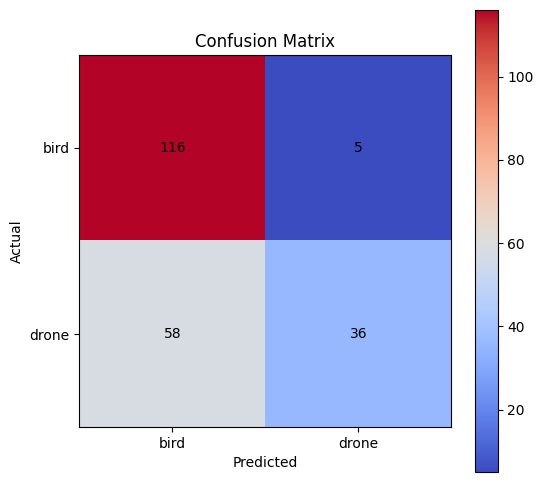

In [4]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

cm = confusion_matrix(test_data.classes, y_pred)

plt.imshow(cm, cmap='coolwarm')
plt.title("Confusion Matrix")
plt.colorbar()

class_names = list(test_data.class_indices.keys())
ticks = np.arange(len(class_names))

plt.xticks(ticks, class_names, rotation=0)
plt.yticks(ticks, class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [7]:
# Class Distribution

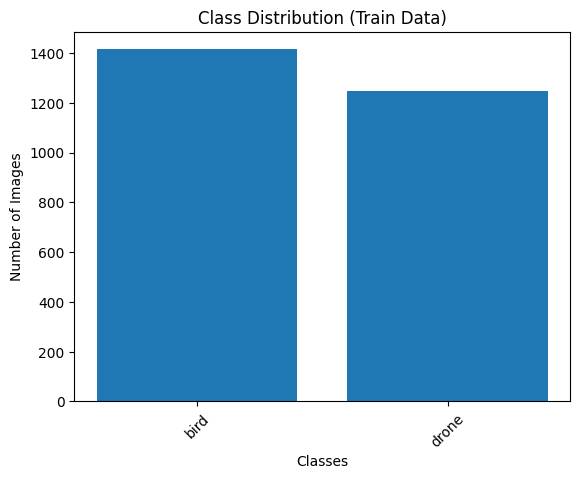

In [5]:
train_counts = [len(os.listdir(os.path.join(train_dir, cls))) 
                for cls in os.listdir(train_dir)]

plt.figure()
plt.bar(os.listdir(train_dir), train_counts)
plt.title("Class Distribution (Train Data)")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [9]:
# Prediction Confidence for ONE Sample

1/1 [==============================] - 1s 977ms/step


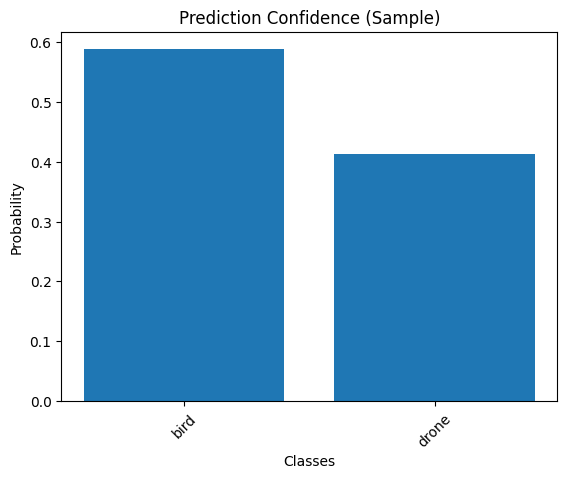

In [6]:
# Pick one sample from test
sample_img, _ = next(test_data)
sample_pred = model.predict(sample_img)

plt.figure()
plt.bar(class_names, sample_pred[0])
plt.title("Prediction Confidence (Sample)")
plt.xlabel("Classes")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.show()

In [11]:
# Precision, Recall, F1 Score Chart

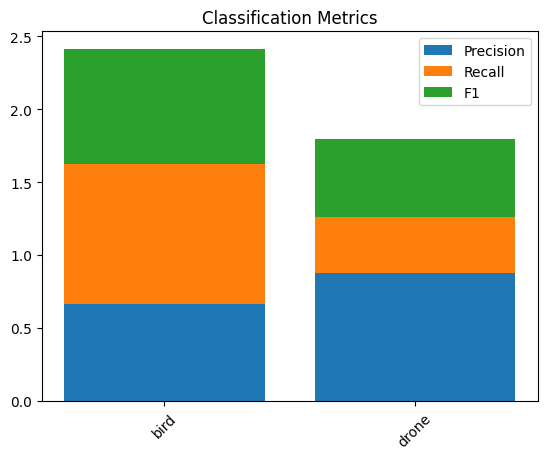

In [7]:
report = classification_report(
    test_data.classes,
    y_pred,
    target_names=class_names,
    output_dict=True
)

precision = [report[c]['precision'] for c in class_names]
recall = [report[c]['recall'] for c in class_names]
f1 = [report[c]['f1-score'] for c in class_names]

x = np.arange(len(class_names))

plt.figure()
plt.bar(x, precision, label='Precision')
plt.bar(x, recall, bottom=precision, label='Recall')
plt.bar(x, f1, bottom=np.array(precision)+np.array(recall), label='F1')

plt.xticks(x, class_names, rotation=45)
plt.title("Classification Metrics")
plt.legend()
plt.show()

In [13]:
# Accuracy vs Loss Combined

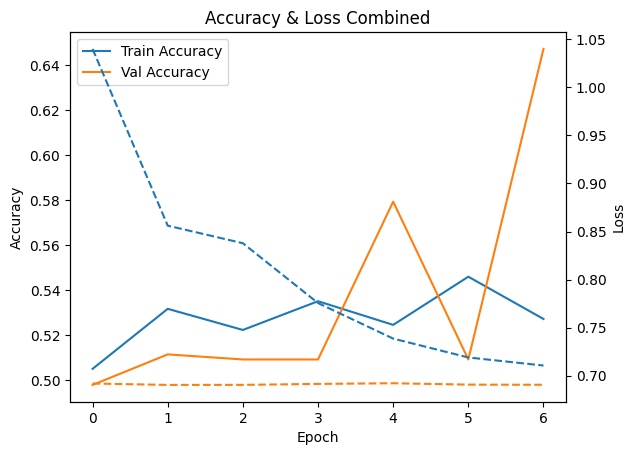

In [8]:
fig, ax = plt.subplots()

ax.plot(history.history['accuracy'], label='Train Accuracy')
ax.plot(history.history['val_accuracy'], label='Val Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend(loc='upper left')

ax2 = ax.twinx()
ax2.plot(history.history['loss'], linestyle='--', label='Train Loss')
ax2.plot(history.history['val_loss'], linestyle='--', label='Val Loss')
ax2.set_ylabel('Loss')

plt.title("Accuracy & Loss Combined")
plt.show()

In [15]:
# Misclassified Images

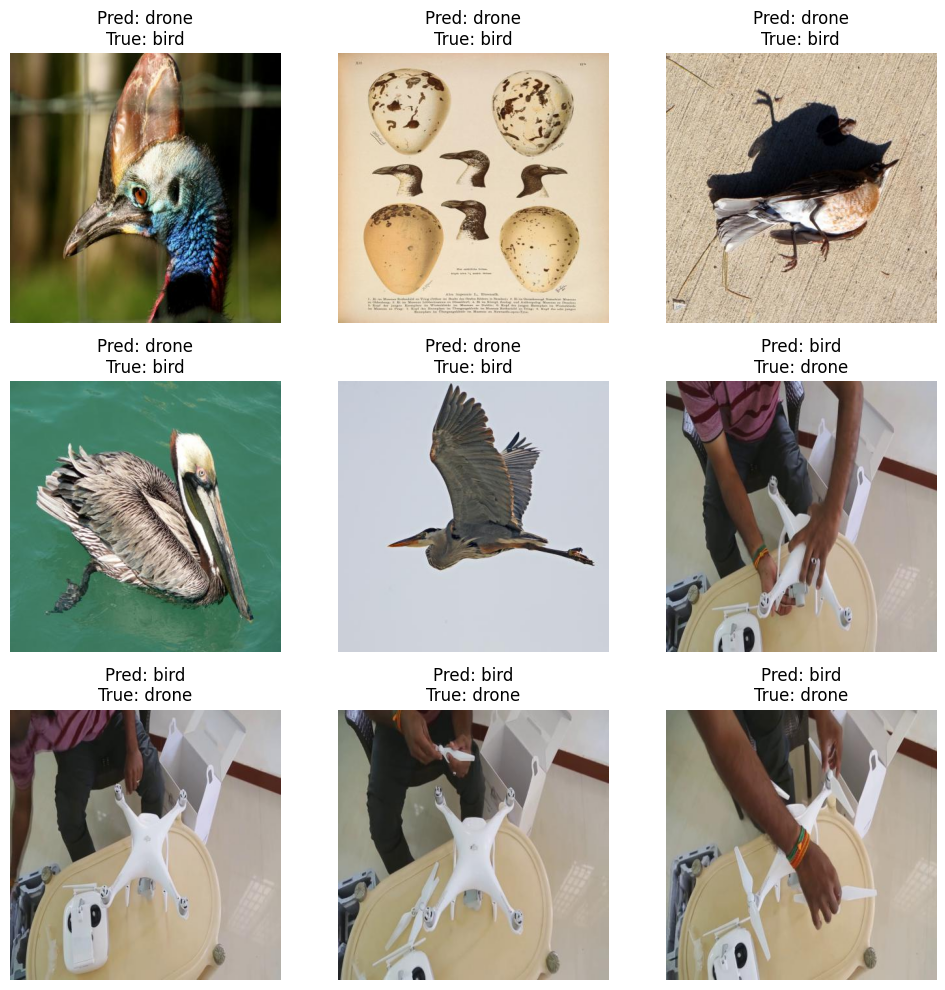

In [9]:
misclassified = np.where(y_pred != test_data.classes)[0]

plt.figure(figsize=(10,10))

for i, idx in enumerate(misclassified[:9]):  # show 9 images
    img_path = test_data.filepaths[idx]
    img = plt.imread(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"Pred: {class_names[y_pred[idx]]}\nTrue: {class_names[test_data.classes[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
# Top-1 Confidence Distribution

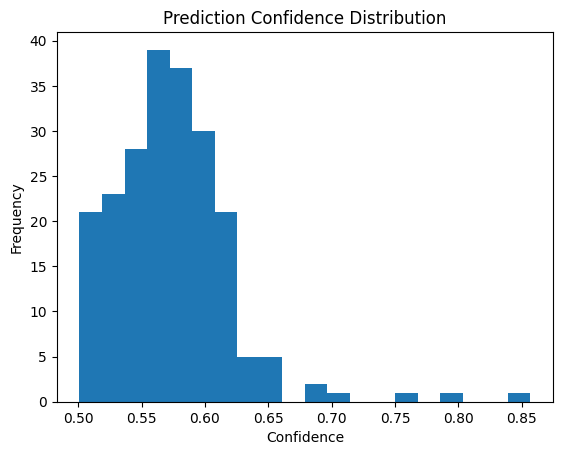

In [10]:
confidence = np.max(predictions, axis=1)

plt.figure()
plt.hist(confidence, bins=20)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

# Conclusion

This project demonstrates the effectiveness of transfer learning in image classification tasks. Using pretrained models like EfficientNet reduces computational cost while achieving high accuracy. The deployed application provides an interactive interface for real-world usage.

Thanks